In [1]:
%cd ..

d:\project\ScratchMLP-SingleChar


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from src.model import MLP
from src.load_data import load_processed_data

In [3]:
data = load_processed_data()
X_train, Y_train, X_val, Y_val, X_test, Y_test = data

print(f"Data shapes:")
print(f"  Train: {X_train.shape[1]} samples")
print(f"  Validation: {X_val.shape[1]} samples")  
print(f"  Test: {X_test.shape[1]} samples")

Data shapes:
  Train: 101520 samples
  Validation: 11280 samples
  Test: 18800 samples


In [4]:
class_names = [
    '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
    'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J',
    'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T',
    'U', 'V', 'W', 'X', 'Y', 'Z',
    'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't'
]

In [5]:
layer_dims = [784, 256, 47]
mlp = MLP(layer_dims=layer_dims, init='he', lr=0.01)

weights = np.load('models/mlp_weights.npz')
for key in weights.keys():
    mlp.parameters[key] = weights[key]
    
print(f"Loaded parameters: {list(weights.keys())}")

Loaded parameters: ['W1', 'b1', 'W2', 'b2']


In [6]:
def evaluate_model(mlp, X, Y, dataset_name):
    AL, _ = mlp.forward(X)
    predictions = np.argmax(AL, axis=0)
    true_labels = np.argmax(Y, axis=0)
    accuracy = np.mean(predictions == true_labels)
    loss = mlp.cost(AL, Y)
    
    print(f"{dataset_name} Results:")
    print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Loss: {loss:.4f}")
    print(f"  Samples: {X.shape[1]}")
    print()
    
    return predictions, true_labels, accuracy, loss

train_preds, train_true, train_acc, train_loss = evaluate_model(mlp, X_train, Y_train, "Training")
val_preds, val_true, val_acc, val_loss = evaluate_model(mlp, X_val, Y_val, "Validation") 
test_preds, test_true, test_acc, test_loss = evaluate_model(mlp, X_test, Y_test, "Test")

Training Results:
  Accuracy: 0.8673 (86.73%)
  Loss: 0.4083
  Samples: 101520

Validation Results:
  Accuracy: 0.8280 (82.80%)
  Loss: 0.5315
  Samples: 11280

Test Results:
  Accuracy: 0.8253 (82.53%)
  Loss: 0.5623
  Samples: 18800



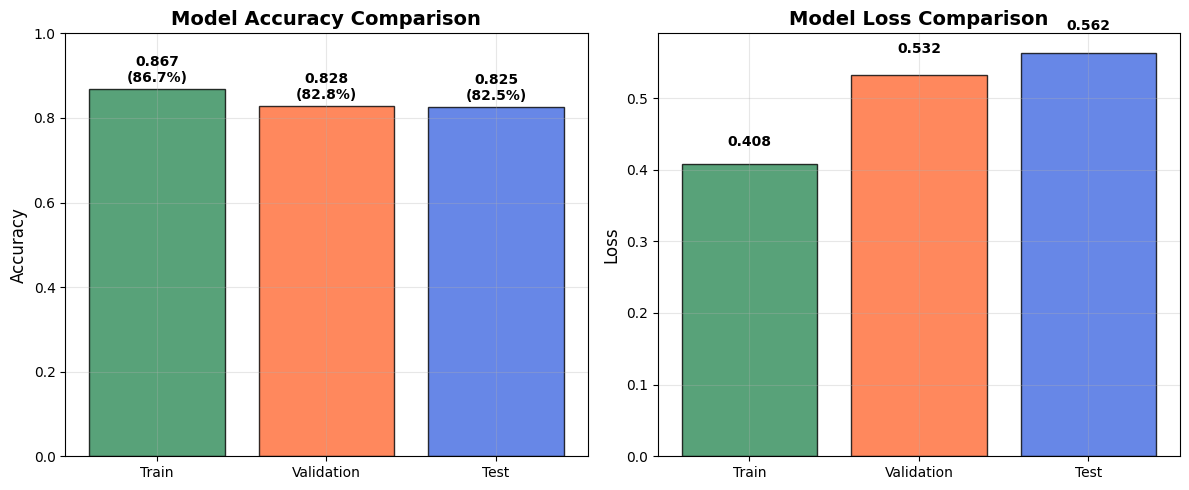

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

datasets = ['Train', 'Validation', 'Test']
accuracies = [train_acc, val_acc, test_acc]
colors = ['#2E8B57', '#FF6B35', '#4169E1']

bars1 = ax1.bar(datasets, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)

for bar, acc in zip(bars1, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{acc:.3f}\n({acc*100:.1f}%)', ha='center', va='bottom', fontweight='bold')

losses = [train_loss, val_loss, test_loss]
bars2 = ax2.bar(datasets, losses, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
ax2.set_title('Model Loss Comparison', fontsize=14, fontweight='bold')
ax2.set_ylabel('Loss', fontsize=12)
ax2.grid(True, alpha=0.3)

for bar, loss in zip(bars2, losses):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + height*0.05,
             f'{loss:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

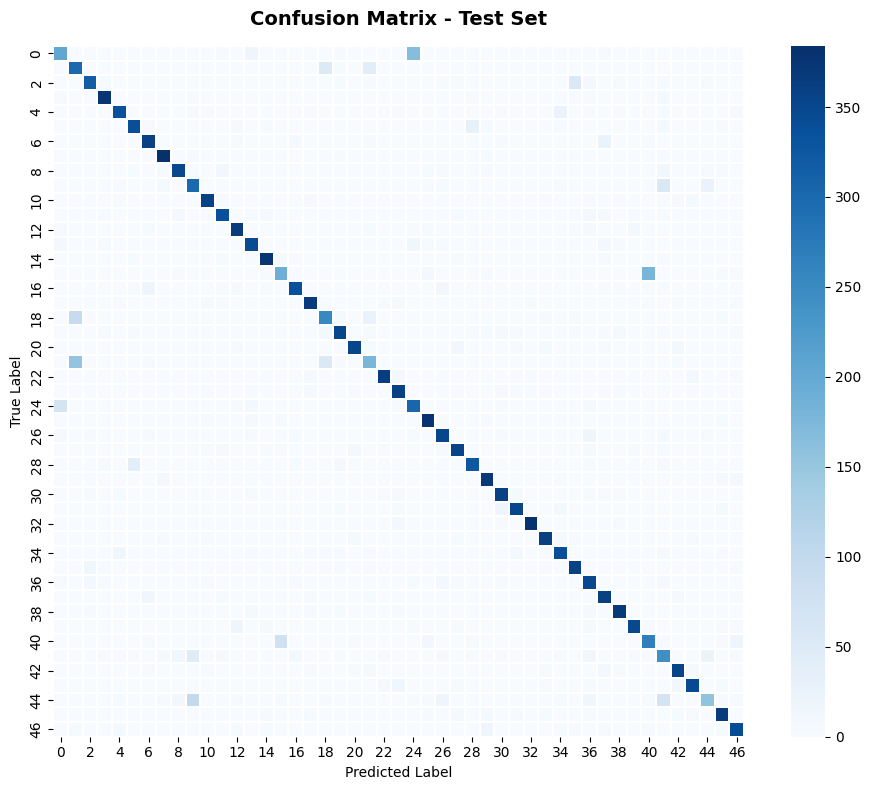

              precision    recall  f1-score   support

           0     0.6812    0.5075    0.5817       400
           1     0.5348    0.7500    0.6243       400
           2     0.8898    0.7875    0.8355       400
           3     0.9238    0.9400    0.9318       400
           4     0.8839    0.8375    0.8601       400
           5     0.8518    0.8475    0.8496       400
           6     0.8686    0.8925    0.8804       400
           7     0.9121    0.9600    0.9354       400
           8     0.8813    0.8725    0.8769       400
           9     0.6500    0.7475    0.6953       400
          10     0.9133    0.8950    0.9040       400
          11     0.8842    0.8400    0.8615       400
          12     0.8795    0.9125    0.8957       400
          13     0.8515    0.8600    0.8557       400
          14     0.9214    0.9375    0.9294       400
          15     0.6667    0.4750    0.5547       400
          16     0.9155    0.8400    0.8761       400
          17     0.9059    

In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(test_true, test_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap='Blues', fmt='d', cbar=True, 
            square=True, linewidths=0.1)
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('True Label', fontsize=10)
plt.tight_layout()
plt.show()

print(classification_report(test_true, test_preds, digits=4))

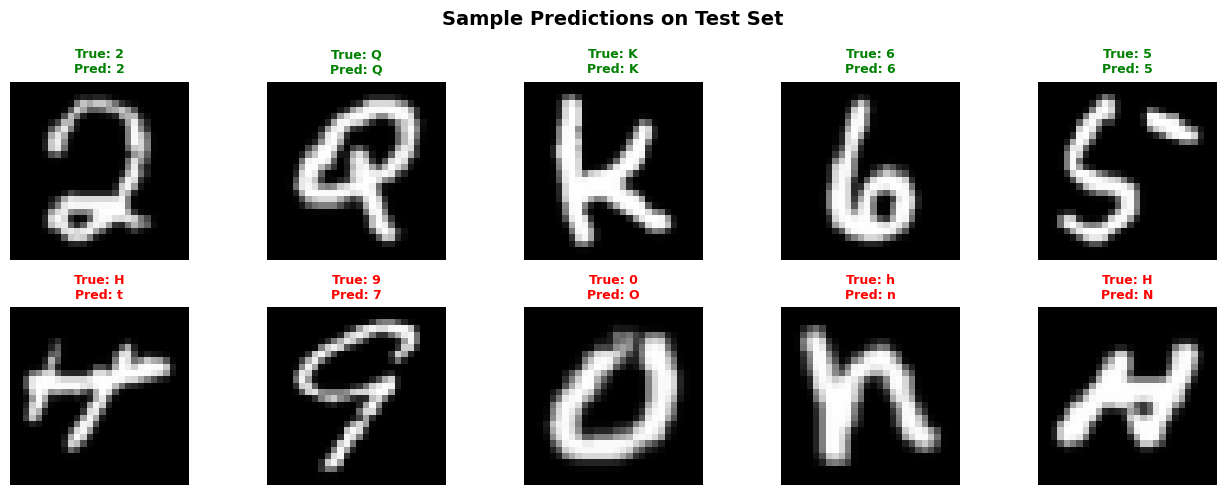

In [9]:
def visualize_predictions(X, predictions, true_labels):
    correct_mask = (predictions == true_labels)
    correct_indices = np.where(correct_mask)[0]
    incorrect_indices = np.where(~correct_mask)[0]
    
    correct_sample = np.random.choice(correct_indices, 5, replace=False)
    incorrect_sample = np.random.choice(incorrect_indices, 5, replace=False)
    
    fig, axes = plt.subplots(2, 5, figsize=(13, 5))
    fig.suptitle('Sample Predictions on Test Set', fontsize=14, fontweight='bold')
    
    for i, idx in enumerate(correct_sample):
        img = X[:, idx].reshape(28, 28).T
        
        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].axis('off')
        
        pred_label = class_names[predictions[idx]]
        true_label = class_names[true_labels[idx]]
        
        axes[0, i].set_title(f'True: {true_label}\nPred: {pred_label}', 
                            color='green', fontweight='bold', fontsize=9)
    
    for i, idx in enumerate(incorrect_sample):
        img = X[:, idx].reshape(28, 28).T
        
        axes[1, i].imshow(img, cmap='gray')
        axes[1, i].axis('off')
        
        pred_label = class_names[predictions[idx]]
        true_label = class_names[true_labels[idx]]
        
        axes[1, i].set_title(f'True: {true_label}\nPred: {pred_label}', 
                            color='red', fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    plt.show()

visualize_predictions(X_test, test_preds, test_true)

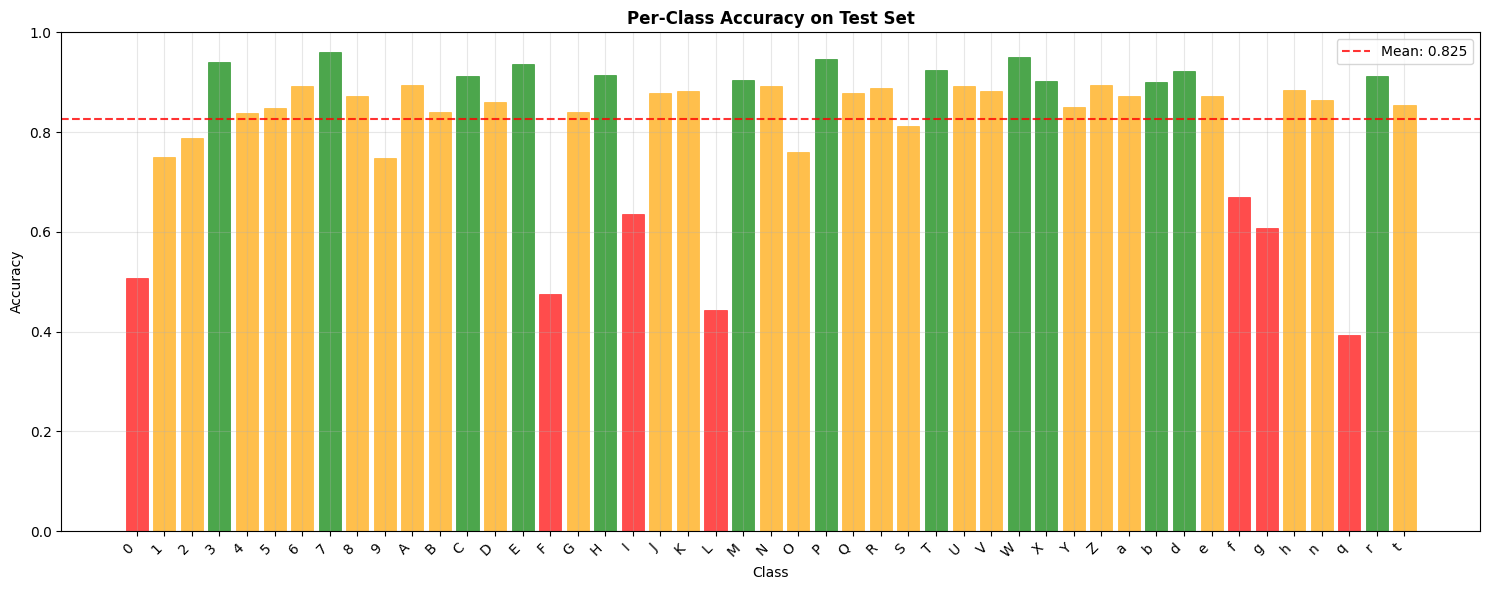

Per-class accuracy statistics:
  Mean: 0.8253
  Std:  0.1363
  Min:  0.3925 (Class 'q')
  Max:  0.9600 (Class '7')

Detailed per-class accuracy:
Class '0': 0.5075 ( 400 samples)
Class '1': 0.7500 ( 400 samples)
Class '2': 0.7875 ( 400 samples)
Class '3': 0.9400 ( 400 samples)
Class '4': 0.8375 ( 400 samples)
Class '5': 0.8475 ( 400 samples)
Class '6': 0.8925 ( 400 samples)
Class '7': 0.9600 ( 400 samples)
Class '8': 0.8725 ( 400 samples)
Class '9': 0.7475 ( 400 samples)
Class 'A': 0.8950 ( 400 samples)
Class 'B': 0.8400 ( 400 samples)
Class 'C': 0.9125 ( 400 samples)
Class 'D': 0.8600 ( 400 samples)
Class 'E': 0.9375 ( 400 samples)
Class 'F': 0.4750 ( 400 samples)
Class 'G': 0.8400 ( 400 samples)
Class 'H': 0.9150 ( 400 samples)
Class 'I': 0.6350 ( 400 samples)
Class 'J': 0.8775 ( 400 samples)
Class 'K': 0.8825 ( 400 samples)
Class 'L': 0.4425 ( 400 samples)
Class 'M': 0.9050 ( 400 samples)
Class 'N': 0.8925 ( 400 samples)
Class 'O': 0.7600 ( 400 samples)
Class 'P': 0.9475 ( 400 sample

In [10]:
def analyze_per_class_accuracy(true_labels, predictions, num_classes=47):
    """Analyze accuracy for each class"""
    class_accuracies = []
    class_counts = []
    
    for class_id in range(num_classes):
        class_mask = (true_labels == class_id)
        class_samples = np.sum(class_mask)
        
        if class_samples > 0:
            class_preds = predictions[class_mask]
            class_true = true_labels[class_mask]
            class_acc = np.mean(class_preds == class_true)
        else:
            class_acc = 0
            
        class_accuracies.append(class_acc)
        class_counts.append(class_samples)
    
    return np.array(class_accuracies), np.array(class_counts)

class_accs, class_counts = analyze_per_class_accuracy(test_true, test_preds)

plt.figure(figsize=(15, 6))
classes = np.arange(47)
bars = plt.bar(classes, class_accs, alpha=0.7, edgecolor='black', linewidth=0.5)

for i, (bar, acc) in enumerate(zip(bars, class_accs)):
    if acc >= 0.9:
        bar.set_color('green')
    elif acc >= 0.7:
        bar.set_color('orange') 
    else:
        bar.set_color('red')

plt.title('Per-Class Accuracy on Test Set', fontsize=12, fontweight='bold')
plt.xlabel('Class', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)

plt.xticks(classes, [class_names[i] for i in classes], rotation=45, ha='right')

mean_acc = np.mean(class_accs)
std_acc = np.std(class_accs)
plt.axhline(y=mean_acc, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_acc:.3f}')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Per-class accuracy statistics:")
print(f"  Mean: {mean_acc:.4f}")
print(f"  Std:  {std_acc:.4f}")
print(f"  Min:  {np.min(class_accs):.4f} (Class '{class_names[np.argmin(class_accs)]}')")
print(f"  Max:  {np.max(class_accs):.4f} (Class '{class_names[np.argmax(class_accs)]}')")

print(f"\nDetailed per-class accuracy:")
print("="*50)
for i, (acc, count) in enumerate(zip(class_accs, class_counts)):
    print(f"Class '{class_names[i]}': {acc:.4f} ({count:4d} samples)")